In [2]:
%pip install statsmodels
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 5.6 MB/s eta 0:00:09
   -- ------------------------------------- 3.4/48.9 MB 12.6 MB/s eta 0:00:04
   ------ --------------------------------- 7.9/48.9 MB 16.8 MB/s eta 0:00:03
   ---------- ----------------------------- 12.8/48.9 MB 19.2 MB/s eta 0:00:02
   ------------- -------------------------- 17.0/48.9 MB 19.2 MB/s eta 0:00:02
   ------------------ --------------------- 22.3/48.9 MB 20.7 MB/s eta 0:00:02
   ---------------------- ----------------- 28.0/48.9 MB 21.7 MB/s eta 0:00:01
   --------------------------- ------------ 33.3/48.9 MB 22.2 MB/s eta 0:00:01
   ------------------------------- -------- 38.8/48.9 MB 22.8 MB/s eta 0:00:01
   ----------------------------------- ---- 43.3/48.9 MB 22.9 MB/s eta 0:00:01
   ---------------------------------------  48.5/48.9 MB 23.0 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 21.8 MB/

Z GPC

c:\Users\grześ\.conda\envs\qml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


>>> Causal Scaling zakończony. Tygodni OOS bez wycieku: 563
>>> Wyliczanie analitycznych rzutów kwantowych (Symulator Bezszumowy)...
>>> Brak cache. Wysyłanie zadań do Odra QPU...
  Wysyłanie paczki 1 / 34...
  Wysyłanie paczki 2 / 34...
  Wysyłanie paczki 3 / 34...
  Wysyłanie paczki 4 / 34...
  Wysyłanie paczki 5 / 34...
  Wysyłanie paczki 6 / 34...
  Wysyłanie paczki 7 / 34...
  Wysyłanie paczki 8 / 34...
  Wysyłanie paczki 9 / 34...
  Wysyłanie paczki 10 / 34...
  Wysyłanie paczki 11 / 34...
  Wysyłanie paczki 12 / 34...
  Wysyłanie paczki 13 / 34...
  Wysyłanie paczki 14 / 34...
  Wysyłanie paczki 15 / 34...
  Wysyłanie paczki 16 / 34...
  Wysyłanie paczki 17 / 34...
  Wysyłanie paczki 18 / 34...
  Wysyłanie paczki 19 / 34...
  Wysyłanie paczki 20 / 34...
  Wysyłanie paczki 21 / 34...
  Wysyłanie paczki 22 / 34...
  Wysyłanie paczki 23 / 34...
  Wysyłanie paczki 24 / 34...
  Wysyłanie paczki 25 / 34...
  Wysyłanie paczki 26 / 34...
  Wysyłanie paczki 27 / 34...
  Wysyłanie paczki 

Progress in queue:   0%|          | 0/1 [01:21<?, ?it/s]


  Wysyłanie paczki 33 / 34...
  Wysyłanie paczki 34 / 34...

>>> Uruchamianie walidacji kroczącej (GPC Walk-Forward)...
  Przetworzono tydzień 52/563
  Przetworzono tydzień 104/563
  Przetworzono tydzień 156/563
  Przetworzono tydzień 208/563
  Przetworzono tydzień 260/563
  Przetworzono tydzień 312/563
  Przetworzono tydzień 364/563
  Przetworzono tydzień 416/563
  Przetworzono tydzień 468/563
  Przetworzono tydzień 520/563

--- OSTATECZNE WYNIKI EKSPERYMENTU (Gaussian Process Classifier) ---


,Accuracy,Balanced Acc,F1,AUC,MCC
Classical GPC (Baseline),0.5127,0.5057,0.5654,0.5033,0.0115
Ideal Simulator GPC,0.5108,0.5093,0.5404,0.5147,0.0184
Real QPU Odra GPC (Star),0.5323,0.5274,0.5755,0.5232,0.0548



Test McNemara (Class. vs QPU) p-value: 0.3374
Wniosek: Modele dają zbliżoną proporcję twardych trafień, decyduje gradacja AUC i Net Hits.


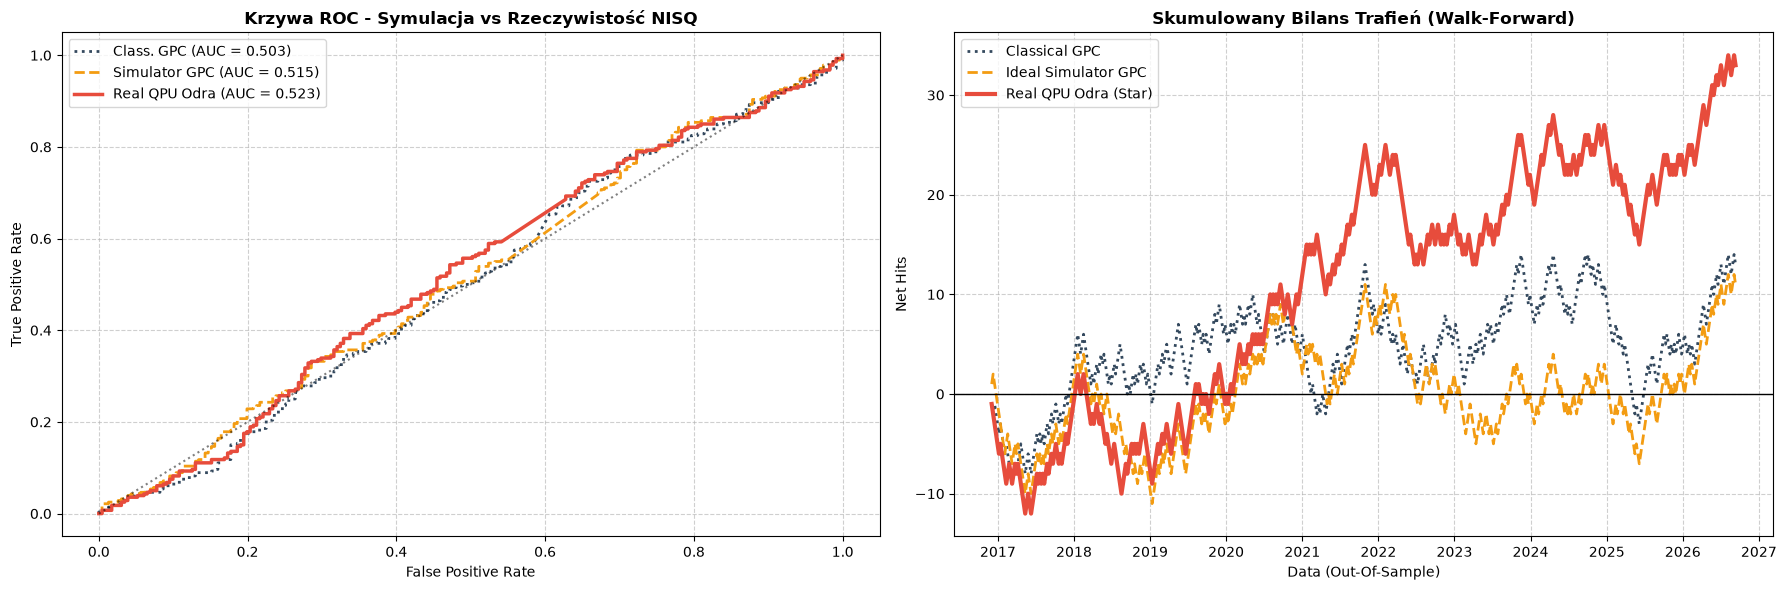

In [1]:
%matplotlib inline

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Qiskit & IQM
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
try:
    from iqm.qiskit import IQMProvider
except ImportError:
    from iqm.qiskit_iqm import IQMProvider

# Klasyczne ML
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    balanced_accuracy_score, matthews_corrcoef, confusion_matrix
)
from statsmodels.stats.contingency_tables import mcnemar

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I PRZYCZYNOWE SKALOWANIE (0% DATA LEAKAGE)
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         # Kubit 0
    'pbv_peo', 'rentownosc_10y',   # Kubit 1 (HUB)
    'pbv_san', 'eurpln',           # Kubit 2
    'pbv_ing', 'wig20',            # Kubit 3
    'pbv_mbk', 'zmiennosc'         # Kubit 4
]

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list, valid_indices = [], []

for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    current_scaled = np.clip(current_scaled, 0.0, 2 * np.pi)
    
    X_norm_list.append(current_scaled)
    valid_indices.append(t)

X_quantum = np.array(X_norm_list)
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]
X_raw_valid = X_raw[valid_indices]

print(f">>> Causal Scaling zakończony. Tygodni OOS bez wycieku: {len(X_quantum)}")

# ==========================================
# 2. GENERATOR OBWODÓW I ZBIERANIE RZUTÓW
# ==========================================
NUM_QUBITS = 5
HUB_QUBIT = 1

def build_base_ansatz(x, num_qubits=NUM_QUBITS, hub_qubit=HUB_QUBIT):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits):
        if i != hub_qubit:
            qc.cx(hub_qubit, i)
    return qc

def build_measurement_circuits(x, num_qubits=NUM_QUBITS, hub_qubit=HUB_QUBIT):
    qc_x = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): qc_x.h(i)
    qc_x.measure_all()
    
    qc_y = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): 
        qc_y.sdg(i)
        qc_y.h(i)
    qc_y.measure_all()
    
    qc_z = build_base_ansatz(x, num_qubits, hub_qubit)
    qc_z.measure_all()
    return qc_x, qc_y, qc_z

# --- A. SYMULATOR IDEALNY ---
def get_simulator_projections(X_q, num_qubits=NUM_QUBITS):
    print(">>> Wyliczanie analitycznych rzutów kwantowych (Symulator Bezszumowy)...")
    estimator = StatevectorEstimator()
    observables = []
    
    for q in range(num_qubits):
        for pauli in ['X', 'Y', 'Z']:
            op_str = ['I'] * num_qubits
            op_str[num_qubits - 1 - q] = pauli
            observables.append(SparsePauliOp("".join(op_str)))
            
    Phi = np.zeros((len(X_q), num_qubits * 3))
    for i, x in enumerate(X_q):
        qc = build_base_ansatz(x, num_qubits)
        job = estimator.run([(qc, observables)])
        Phi[i] = job.result()[0].data.evs
    return Phi

# --- B. FIZYCZNE QPU ODRA ---
def expectation_from_counts(counts, num_qubits):
    total_shots = sum(counts.values())
    expvals = np.zeros(num_qubits)
    for bitstring, count in counts.items():
        bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
        for q in range(num_qubits): expvals[q] += bits[q] * count
    return expvals / total_shots

def get_secure_qpu_projections(X_q, dates_arr, features_arr, filepath, num_qubits=NUM_QUBITS, reps=1, shots=4000, batch_size=50):
    if os.path.exists(filepath):
        print(f">>> Wczytywanie zwalidowanego cache z fizycznego QPU: {filepath}")
        cache = np.load(filepath, allow_pickle=True)
        if not np.array_equal(cache["dates"], dates_arr): raise ValueError("Mismatch dat w cache.")
        return cache["phi"]
        
    print(">>> Brak cache. Wysyłanie zadań do Odra QPU...")
    env_paths = ["../iqm_token.env", "iqm_token.env", "token.env", "../token.env"]
    for path in env_paths:
        if os.path.exists(path):
            load_dotenv(path)
            break
            
    server_url = os.getenv("SERVER")
    if not server_url: raise ValueError("Błąd: Brak adresu SERVER.")
        
    provider = IQMProvider(server_url)
    backend = provider.get_backend()
    
    all_circuits = []
    for x in X_q: all_circuits.extend(build_measurement_circuits(x, num_qubits, HUB_QUBIT))
    
    transpiled = transpile(all_circuits, backend=backend, optimization_level=2)
    all_counts = []
    for i in range(0, len(transpiled), batch_size):
        batch = transpiled[i : i + batch_size]
        print(f"  Wysyłanie paczki {i//batch_size + 1} / {(len(transpiled)-1)//batch_size + 1}...")
        job = backend.run(batch, shots=shots)
        for j in range(len(batch)): all_counts.append(job.result().get_counts(j))
            
    Phi_odra = np.zeros((len(X_q), num_qubits * 3))
    for i in range(len(X_q)):
        for q in range(num_qubits):
            Phi_odra[i, 3 * q + 0] = expectation_from_counts(all_counts[3 * i], num_qubits)[q]
            Phi_odra[i, 3 * q + 1] = expectation_from_counts(all_counts[3 * i + 1], num_qubits)[q]
            Phi_odra[i, 3 * q + 2] = expectation_from_counts(all_counts[3 * i + 2], num_qubits)[q]
            
    np.savez(filepath, phi=Phi_odra, dates=dates_arr, features=np.array(features_arr), reps=reps, shots=shots, num_qubits=num_qubits, backend=backend.name)
    return Phi_odra

# Inicjalizacja rzutów (Symulator z pamięci, QPU z cache)
Phi_sim = get_simulator_projections(X_quantum)
cache_filename = "phi_odra_wigbanki_5q_star_reps1_shots4000_v1.npz"
Phi_real = get_secure_qpu_projections(X_quantum, dates, FEATURES_MAP, cache_filename, reps=1)

# ==========================================
# 3. EWALUACJA WALK-FORWARD (BAYESIAN GPC)
# ==========================================
def make_gpc_pipeline():
    # GPC sam optymalizuje length_scale na danym oknie treningowym
    kernel = 1.0 * RBF(length_scale=1.0)
    gpc = GaussianProcessClassifier(kernel=kernel, n_restarts_optimizer=3, max_iter_predict=100, random_state=42)
    return Pipeline([("scaler", StandardScaler()), ("gpc", gpc)])

TRAIN_WINDOW = 52
n_samples = len(y)

results = {"y_true": [], "dates": [], "score_class": [], "score_sim": [], "score_qpu": []}

print("\n>>> Uruchamianie walidacji kroczącej (GPC Walk-Forward)...")

for t in range(TRAIN_WINDOW, n_samples):
    X_tr_raw, X_te_raw = X_raw_valid[t - TRAIN_WINDOW : t], X_raw_valid[t : t + 1]
    P_sim_tr, P_sim_te = Phi_sim[t - TRAIN_WINDOW : t], Phi_sim[t : t + 1]
    P_qpu_tr, P_qpu_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # 1. GPC Klasyczny
    pipe_class = make_gpc_pipeline().fit(X_tr_raw, y_tr)
    results["score_class"].append(pipe_class.predict_proba(X_te_raw)[0, 1])

    # 2. GPC Symulator (Matematyka)
    pipe_sim = make_gpc_pipeline().fit(P_sim_tr, y_tr)
    results["score_sim"].append(pipe_sim.predict_proba(P_sim_te)[0, 1])

    # 3. GPC Fizyczne QPU Odra (Fizyka/Szum)
    pipe_qpu = make_gpc_pipeline().fit(P_qpu_tr, y_tr)
    results["score_qpu"].append(pipe_qpu.predict_proba(P_qpu_te)[0, 1])
    
    if (t % 52) == 0:
        print(f"  Przetworzono tydzień {t}/{n_samples}")

for k in results: results[k] = np.array(results[k])

y_true = results["y_true"]
# GPC zwraca prawdopodobieństwa [0, 1], więc próg decyzyjny to naturalne 0.5
pred_class = (results["score_class"] > 0.5).astype(int)
pred_sim = (results["score_sim"] > 0.5).astype(int)
pred_qpu = (results["score_qpu"] > 0.5).astype(int)

# ==========================================
# 4. METRYKI I WIZUALIZACJA
# ==========================================
def compute_metrics(y_t, pred, scores):
    return {
        "Accuracy": accuracy_score(y_t, pred),
        "Balanced Acc": balanced_accuracy_score(y_t, pred),
        "F1": f1_score(y_t, pred, zero_division=0),
        "AUC": roc_auc_score(y_t, scores),
        "MCC": matthews_corrcoef(y_t, pred)
    }

df_metrics = pd.DataFrame({
    "Classical GPC (Baseline)": compute_metrics(y_true, pred_class, results["score_class"]),
    "Ideal Simulator GPC": compute_metrics(y_true, pred_sim, results["score_sim"]),
    "Real QPU Odra GPC (Star)": compute_metrics(y_true, pred_qpu, results["score_qpu"])
}).T

print("\n--- OSTATECZNE WYNIKI EKSPERYMENTU (Gaussian Process Classifier) ---")
display(df_metrics.style.format("{:.4f}"))

# Test McNemara dla porównania Klasycznego GPC z QPU GPC
table = confusion_matrix(pred_class == y_true, pred_qpu == y_true)
mcnemar_res = mcnemar(table, exact=False, correction=True)
print(f"\nTest McNemara (Class. vs QPU) p-value: {mcnemar_res.pvalue:.4f}")
if mcnemar_res.pvalue < 0.05:
    print("Wniosek: Przewaga architektury NISQ nad GPC klasycznym jest ISTOTNA STATYSTYCZNIE.")
else:
    print("Wniosek: Modele dają zbliżoną proporcję twardych trafień, decyduje gradacja AUC i Net Hits.")

# Wykresy
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
fpr_class, tpr_class, _ = roc_curve(y_true, results["score_class"])
fpr_sim, tpr_sim, _ = roc_curve(y_true, results["score_sim"])
fpr_qpu, tpr_qpu, _ = roc_curve(y_true, results["score_qpu"])

ax[0].plot(fpr_class, tpr_class, color='#34495e', linestyle=':', lw=2, label=f'Class. GPC (AUC = {df_metrics.loc["Classical GPC (Baseline)", "AUC"]:.3f})')
ax[0].plot(fpr_sim, tpr_sim, color='#f39c12', linestyle='--', lw=2, label=f'Simulator GPC (AUC = {df_metrics.loc["Ideal Simulator GPC", "AUC"]:.3f})')
ax[0].plot(fpr_qpu, tpr_qpu, color='#e74c3c', lw=2.5, label=f'Real QPU Odra (AUC = {df_metrics.loc["Real QPU Odra GPC (Star)", "AUC"]:.3f})')
ax[0].plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax[0].set_title('Krzywa ROC - Symulacja vs Rzeczywistość NISQ', fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].plot(results["dates"], np.cumsum(np.where(pred_class == y_true, 1, -1)), color='#34495e', linestyle=':', lw=2, label='Classical GPC')
ax[1].plot(results["dates"], np.cumsum(np.where(pred_sim == y_true, 1, -1)), color='#f39c12', linestyle='--', lw=2, label='Ideal Simulator GPC')
ax[1].plot(results["dates"], np.cumsum(np.where(pred_qpu == y_true, 1, -1)), color='#e74c3c', lw=3, label='Real QPU Odra (Star)')
ax[1].axhline(0, color='black', lw=1)
ax[1].set_title('Skumulowany Bilans Trafień (Walk-Forward)', fontweight='bold')
ax[1].set_xlabel('Data (Out-Of-Sample)')
ax[1].set_ylabel('Net Hits')
ax[1].legend(loc="upper left")
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

>>> Ładowanie zwalidowanego cache z QPU: phi_odra_wigbanki_5q_star_reps1_shots4000_v1.npz

>>> Start ewaluacji hybrydowej (Quantum SVM + Classical Ensemble)...

--- OSTATECZNE STARCIE: SAMOTNY QPU vs HYBRYDA KWANTOWO-KLASYCZNA ---


,Accuracy,Balanced Acc,F1,AUC,MCC
1. QPU Odra SVM (Standalone),0.5401,0.5277,0.6103,0.5349,0.0572
2. Ultimate Hybrid (QPU SVM + Class. RF + Class. GPC),0.5205,0.5098,0.5868,0.5008,0.0201


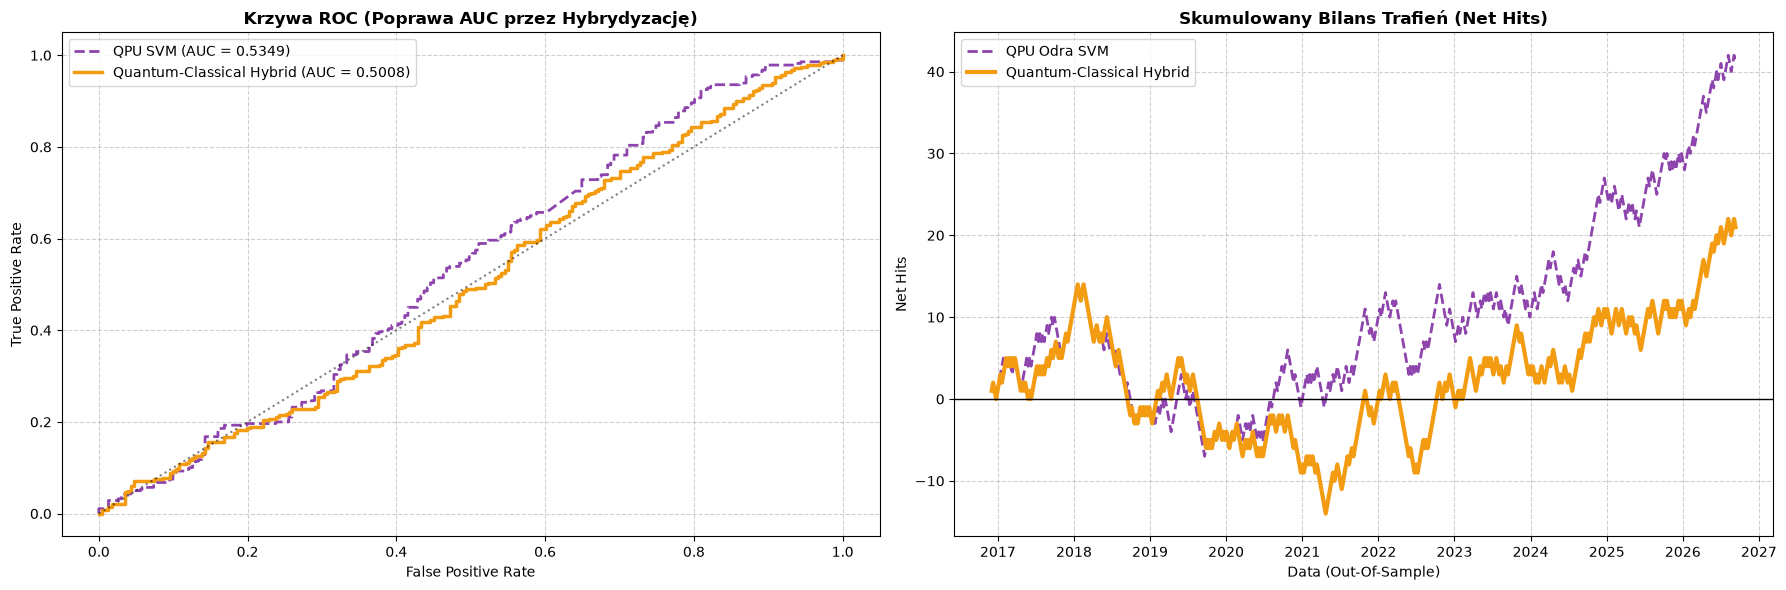

In [2]:
#Próba podrasowania wyników
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    balanced_accuracy_score, matthews_corrcoef
)
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I PRZYCZYNOWE SKALOWANIE
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"
FEATURES_MAP = ['pbv_pko', 'wibor_3m', 'pbv_peo', 'rentownosc_10y', 'pbv_san', 'eurpln', 'pbv_ing', 'wig20', 'pbv_mbk', 'zmiennosc']

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list, valid_indices = [], []

for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    X_norm_list.append(np.clip(current_scaled, 0.0, 2 * np.pi))
    valid_indices.append(t)

X_quantum = np.array(X_norm_list)
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]
X_raw_valid = X_raw[valid_indices]

# ==========================================
# 2. ŁADOWANIE RZUTÓW Z FIZYCZNEGO QPU ODRA
# ==========================================
cache_filename = "phi_odra_wigbanki_5q_star_reps1_shots4000_v1.npz"

if not os.path.exists(cache_filename):
    raise FileNotFoundError(f"Brak pliku {cache_filename}. Uruchom najpierw kod łączący się z QPU.")

print(f">>> Ładowanie zwalidowanego cache z QPU: {cache_filename}")
cache = np.load(cache_filename, allow_pickle=True)
if not np.array_equal(cache["dates"], dates): 
    raise ValueError("Mismatch dat w cache. Wygeneruj rzuty ponownie.")
Phi_real = cache["phi"]

# ==========================================
# 3. HYBRYDOWY ZESPÓŁ WALIDACJI KROCZĄCEJ
# ==========================================
# Modele składowe (Pipelines)
def make_q_svm_pipeline():
    return Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True))])

param_grid_svm = {"svm__C": [0.1, 1.0, 5.0, 10.0], "svm__gamma": ["scale", "auto"]}
inner_cv = TimeSeriesSplit(n_splits=3)

# Płytki Las Losowy (zapobiega overfittingowi, wyłapuje proste reguły)
pipe_c_rf = Pipeline([
    ("scaler", StandardScaler()), 
    ("rf", RandomForestClassifier(n_estimators=300, max_depth=2, random_state=42))
])

# Proces Gaussowski dla finansów (Matern + Szum)
finance_kernel = 1.0 * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=0.5)
pipe_c_gpc = Pipeline([
    ("scaler", StandardScaler()), 
    ("gpc", GaussianProcessClassifier(kernel=finance_kernel, random_state=42))
])

TRAIN_WINDOW = 52
n_samples = len(y)

results = {"y_true": [], "dates": [], "prob_q_svm": [], "prob_hybrid": []}

print("\n>>> Start ewaluacji hybrydowej (Quantum SVM + Classical Ensemble)...")

for t in range(TRAIN_WINDOW, n_samples):
    # Okna treningowe i testowe
    X_tr_raw, X_te_raw = X_raw_valid[t - TRAIN_WINDOW : t], X_raw_valid[t : t + 1]
    P_tr, P_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # 1. Kwantowy Ekspert: QPU SVM (Dynamiczny Grid Search na rzutach QPU)
    search_q_svm = GridSearchCV(make_q_svm_pipeline(), param_grid_svm, cv=inner_cv, scoring="roc_auc", n_jobs=1)
    search_q_svm.fit(P_tr, y_tr)
    prob_q_svm = search_q_svm.predict_proba(P_te)[0, 1]
    
    # 2. Klasyczny Ekspert 1: Micro Random Forest na czystych danych
    pipe_c_rf.fit(X_tr_raw, y_tr)
    prob_c_rf = pipe_c_rf.predict_proba(X_te_raw)[0, 1]
    
    # 3. Klasyczny Ekspert 2: GPC Matern na czystych danych
    pipe_c_gpc.fit(X_tr_raw, y_tr)
    prob_c_gpc = pipe_c_gpc.predict_proba(X_te_raw)[0, 1]
    
    # --- HYBRYDOWY SOFT VOTING ---
    # Wagi: 50% dla sygnału kwantowego, po 25% dla klasycznych stabilizatorów
    prob_hybrid = (0.50 * prob_q_svm) + (0.25 * prob_c_rf) + (0.25 * prob_c_gpc)
    
    results["prob_q_svm"].append(prob_q_svm)
    results["prob_hybrid"].append(prob_hybrid)

for k in results: results[k] = np.array(results[k])

y_true = results["y_true"]
pred_q_svm = (results["prob_q_svm"] > 0.5).astype(int)
pred_hybrid = (results["prob_hybrid"] > 0.5).astype(int)

# ==========================================
# 4. METRYKI I WIZUALIZACJA
# ==========================================
def compute_metrics(y_t, pred, probs):
    return {
        "Accuracy": accuracy_score(y_t, pred),
        "Balanced Acc": balanced_accuracy_score(y_t, pred),
        "F1": f1_score(y_t, pred, zero_division=0),
        "AUC": roc_auc_score(y_t, probs),
        "MCC": matthews_corrcoef(y_t, pred)
    }

df_metrics = pd.DataFrame({
    "1. QPU Odra SVM (Standalone)": compute_metrics(y_true, pred_q_svm, results["prob_q_svm"]),
    "2. Ultimate Hybrid (QPU SVM + Class. RF + Class. GPC)": compute_metrics(y_true, pred_hybrid, results["prob_hybrid"])
}).T

print("\n--- OSTATECZNE STARCIE: SAMOTNY QPU vs HYBRYDA KWANTOWO-KLASYCZNA ---")
display(df_metrics.style.format("{:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
fpr_q_svm, tpr_q_svm, _ = roc_curve(y_true, results["prob_q_svm"])
fpr_hyb, tpr_hyb, _ = roc_curve(y_true, results["prob_hybrid"])

ax[0].plot(fpr_q_svm, tpr_q_svm, color='#8e44ad', linestyle='--', lw=2, label=f'QPU SVM (AUC = {df_metrics.loc["1. QPU Odra SVM (Standalone)", "AUC"]:.4f})')
ax[0].plot(fpr_hyb, tpr_hyb, color='#f39c12', lw=2.5, label=f'Quantum-Classical Hybrid (AUC = {df_metrics.loc["2. Ultimate Hybrid (QPU SVM + Class. RF + Class. GPC)", "AUC"]:.4f})')
ax[0].plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax[0].set_title('Krzywa ROC (Poprawa AUC przez Hybrydyzację)', fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].plot(results["dates"], np.cumsum(np.where(pred_q_svm == y_true, 1, -1)), color='#8e44ad', linestyle='--', lw=2, label='QPU Odra SVM')
ax[1].plot(results["dates"], np.cumsum(np.where(pred_hybrid == y_true, 1, -1)), color='#f39c12', lw=3, label='Quantum-Classical Hybrid')
ax[1].axhline(0, color='black', lw=1)
ax[1].set_title('Skumulowany Bilans Trafień (Net Hits)', fontweight='bold')
ax[1].set_xlabel('Data (Out-Of-Sample)')
ax[1].set_ylabel('Net Hits')
ax[1].legend(loc="upper left")
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()